Will be using the network in EI_STDP.ipynb where STDP is implemented on the synapses to the inhibitory neuron.
This seems to help the network find a steady state.

Here we will try to assess how the autapse actually influences synchrony. 
Factors to consider are:

    - Is it due to the extra current? Try adding a little extra injected current to the non-autaptic E1

    - Is it due to the waveform? Try different form factors with same net current (step current, reverse exponential, biexponential?)

    - Is it timing of the autapse? Randomise the autapse current after every spike...


In [1]:
''' import aqua '''
from aqua.batchAQUA_general import batchAQUA
from aqua.AQUA_general import AQUA
from aqua.utils import * 
from aqua.plotting_functions import *

'''general imports''' 
import numpy as np
import pandas as pd
from brian2 import *
import matplotlib.pyplot as plt
import seaborn as sns
import pyspike as spk
from scipy.signal import convolve, windows, find_peaks, peak_widths
from scipy.stats import wasserstein_distance

from FT_metrics import *

WARNING    /home/liam/anaconda3/envs/aqua/lib/python3.14/site-packages/pyspike/__init__.py:40: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
 [py.warnings]


In [2]:
I_neuron = {'name': 'FS', 'C': 20, 'k': 1, 'v_r': -55, 'v_t': -40, 'v_peak': 25,
     'a': 0.2, 'b': -2, 'c': -45, 'd': 0, 'e': 0.2, 'f': 0., 'tau': 0.}

# strong autaptic neuron on RS resonator...
E1_neuron = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': 5, 'c': -50, 'd': 100, 'e': 0.2, 'f': 250., 'tau': 0.}     # instantaneous autapse bc all synapses are instant.

# non-autaptic neuron - RS resonator
E2_neuron = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': 5, 'c': -50, 'd': 100, 'e': 0., 'f': 0., 'tau': 0.}

def visualise_connectivity(S):
    Ns = len(S.source)
    Nt = len(S.target)
    figure(figsize=(10, 4))
    subplot(121)
    plot(zeros(Ns), arange(Ns), 'ok', ms=10)
    plot(ones(Nt), arange(Nt), 'ok', ms=10)
    for i, j in zip(S.i, S.j):
        plot([0, 1], [i, j], '-k')
    xticks([0, 1], ['Source', 'Target'])
    ylabel('Neuron index')
    xlim(-0.1, 1.1)
    ylim(-1, max(Ns, Nt))
    subplot(122)
    plot(S.i, S.j, 'ok')
    xlim(-1, Ns)
    ylim(-1, Nt)
    xlabel('Source neuron index')
    ylabel('Target neuron index')

In [3]:
### Store the simulation parameters below. 

# DRIVING CURRENTS
INPUT_E1 = 220
INPUT_E2 = 150

# SYNAPSE STRENGTH
E1_TO_E2 = 80   
E2_TO_E1 = 80

#  INHIBITORY PARAMETERS
THRESHOLD_OFFSET = 0
W_MAX = 100

# simulation parameters
T = 5000 # ms
dt = 0.1
N_iter = int(T/dt)


In [ ]:
'''
- - - 3 neuron circuit with an autapse present - - - 
'''
start_scope()

# define the synapse at the population level, defined for excitatory and inhibitory populations
syn_eq = """
    dSyn_exc/dt = -(Syn_exc/t_exc)/ms : 1 
    t_exc : 1
    dSyn_inh/dt = -(Syn_inh/t_inh)/ms : 1 
    t_inh : 1
    g_total = Syn_exc + Syn_inh : 1 

"""

''' - - - define the excitatory population - - - '''
# neuron parameters
params_E = [E1_neuron, E2_neuron]      # 2 neurons

x_start = np.full(shape = (2, 3), fill_value = np.array([-60, 0, 0]))
t_start = np.zeros(2)

# create the batch
batch_E = batchAQUA(params_E)
batch_E.Initialise(x_start, t_start)

# create the input current - STEP CURRENT
I_h1 = INPUT_E1                          # driving current to autaptic neuron
I1 = I_h1 * np.ones(N_iter)         # stronger driving current to E1s
I_h2 = INPUT_E2                          # driving current to non-autaptic neuron
I2 = I_h2 * np.ones(N_iter)         # weaker current to E2

I_inj = np.array([I1, I2])
I_excTA = TimedArray(values = I_inj.T, dt = dt*ms, name = 'I_excTA')

# convert to brian2 with the standard autapse model
E, aut_E = batch_E.meetBrian(stimulus_name = I_excTA, synapse_eq = syn_eq)

''' - - - define the inhibitory neuron - - - '''
param_I = [I_neuron]
x_start = np.array([[-60, 0, 0]])
t_start = np.array([0.])

# create batch 
batch_I = batchAQUA(param_I)
batch_I.Initialise(x_start, t_start)

# input current will be just subthreshold
threshold, _ = batch_I.get_threshold(idx = 0)
I_inh = np.array([(threshold - THRESHOLD_OFFSET)*np.ones(N_iter)])
I_inhTA = TimedArray(values = I_inh.T, dt = dt*ms, name = 'I_inhTA')

# create brian objects, no effective autapse here.
I, aut_I = batch_I.meetBrian(stimulus_name = I_inhTA, synapse_eq = syn_eq)


''' - - - create the synapses - - - '''
# create the synapses between E1 and E2...
# I_syn represents the synapse strength
#syn_eq = """
#dI_syn/dt = -(I_syn/t_syn)/ms : 1 (clock-driven)
#t_syn : 1
#w_syn : 1
#g_total_syn = I_syn : 1 
#"""
model_exc = '''w_exc : 1'''
model_inh = '''w_inh : 1'''
syn_on_pre_exc = '''Syn_exc += w_exc'''     # excitatory presynaptic neuron
syn_on_pre_inh = '''Syn_inh += w_inh'''     # inhibitory presynaptic neuron

""" - - STDP - - """
w_max = W_MAX # maximum allowed current through an inhibitory synapse
taupre = taupost = 20 * ms
dApre = 20      # the maximum change in the weight in one step
dApost = -dApre * (taupre/taupost) * 1.05


model_stdp = '''
w_inh : 1
w_exc : 1
dApre/dt = -Apre / taupre : 1 (event-driven)
dApost/dt = -Apost / taupost : 1 (event-driven)
'''
# if pre- is inhibitory
on_pre_stdp_inh = '''
Syn_inh += w_inh
Apre += dApre
w_inh = clip(w_inh + Apost, -w_max, 0)
''' 
# if pre- is excitatory
on_pre_stdp_exc = '''
Syn_exc += w_exc
Apre += dApre
w_exc = clip(w_exc + Apost, 0, w_max)
''' 
on_post_stdp = '''
Apost += dApost
w_inh = clip(w_inh + Apre, 0, w_max)
w_exc = clip(w_exc + Apre, 0, w_max)
'''

'''exc. synapses'''
# fully connect excitatory neurons (ignoring autapses)
syn_E = Synapses(E, E, 
                model = model_exc,
                on_pre = syn_on_pre_exc,
                method = 'rk2')
syn_E.connect(condition = 'i != j')     # fully connected minus autapses

## Set exc. synapse variables here...
E.Syn_exc = 0            # pA
E.t_exc = 5              # ms
syn_E.w_exc[0, 1] = E1_TO_E2    # pA, weight from E1 -> E2
syn_E.w_exc[1, 0] = E2_TO_E1    # pA, weight from E2 -> E1

'''inh. to exc. synapses'''
syn_IE = Synapses(I, E,
                model = model_stdp,
                on_pre = on_pre_stdp_inh,
                on_post = on_post_stdp,
                method = 'rk2')
syn_IE.connect()         # fully connected to the 2 exc. neurons

## set inh. synapse variables for post-synaptic population
E.Syn_inh = 0
E.t_inh = 5                # ms
syn_IE.w_inh[0, 0] = -50   # pA, weight from I -> E1
syn_IE.w_inh[0, 1] = -50   # pA, weight from I -> E2
# alt., syn_I.w_syn[0, :] = 50, as they are equal

'''exc. to inh. synapses'''
syn_EI = Synapses(E, I,
                model = model_stdp,
                on_pre = on_pre_stdp_exc,
                on_post = on_post_stdp,
                method = 'rk2')
syn_EI.connect()         # both excitatory neurons connect to I

## set inh. synapse variables for post-syn population
I.Syn_exc = 0.            # initially no current through the synapse
I.t_exc = 5               # ms
I.t_inh = 5
syn_EI.w_exc[0, 0] = 50   # pA, weight from I -> E1
syn_EI.w_exc[1, 0] = 50   # pA, weight from I -> E2
# alt., syn_I.w_syn[0, :] = 50, as they are equal

''' - - simulation - - '''
# set simulation parameters
defaultclock.dt = dt*ms
# Monitors
M_v_E_aut = StateMonitor(E, ['v', 'Syn_exc', 'Syn_inh', 'w'], record = True)
M_v_I_aut = StateMonitor(I, ['v', 'Syn_exc', 'Syn_inh'], record = True)
spikemon_E_aut = SpikeMonitor(E, record = True)
spikemon_I_aut = SpikeMonitor(I, record = True)
M_syn_EI_aut = StateMonitor(syn_EI, 'w_exc', record = True)
M_syn_IE_aut = StateMonitor(syn_IE, 'w_inh', record = True)
# M_syn_E = StateMonitor(syn_E, 'Syn_exc', record = True)   # record the current through the synapse
# M_syn_IE = StateMonitor(syn_IE, 'Syn_inh', record = True)   
# M_syn_EI = StateMonitor(syn_EI, 'Syn_exc', record = True)   

# create networks
net = Network(E, I, aut_E, aut_I, syn_E, syn_IE, syn_EI, M_v_E_aut, M_v_I_aut, spikemon_E_aut, spikemon_I_aut, M_syn_IE_aut, M_syn_EI_aut) #, M_syn_E, M_syn_IE, M_syn_EI)

net.run(T*ms)

spike_trains_E_aut = spikemon_E_aut.spike_trains()
spike_trains_I_aut = spikemon_I_aut.spike_trains()

- - threshold - -


100%|██████████| 59999/59999 [00:07<00:00, 7969.43it/s]


ALL FS!!!


In [5]:
'''
- - - 3 neuron circuit - no autapse - - - 
'''
start_scope()

# define the synapse at the population level, defined for excitatory and inhibitory populations
syn_eq = """
    dSyn_exc/dt = -(Syn_exc/t_exc)/ms : 1 
    t_exc : 1
    dSyn_inh/dt = -(Syn_inh/t_inh)/ms : 1 
    t_inh : 1
    g_total = Syn_exc + Syn_inh : 1 

"""

''' - - - define the excitatory population - - - '''
# neuron parameters
params_E = [E2_neuron, E2_neuron]      # 2 neurons

x_start = np.full(shape = (2, 3), fill_value = np.array([-60, 0, 0]))
t_start = np.zeros(2)

# create the batch
batch_E = batchAQUA(params_E)
batch_E.Initialise(x_start, t_start)

# create the input current - STEP CURRENT
I_h1 = INPUT_E1                          # driving current to autaptic neuron
I1 = I_h1 * np.ones(N_iter)         # stronger driving current to E1s
I_h2 = INPUT_E2                          # driving current to non-autaptic neuron
I2 = I_h2 * np.ones(N_iter)         # weaker current to E2

I_inj = np.array([I1, I2])
I_excTA = TimedArray(values = I_inj.T, dt = dt*ms, name = 'I_excTA')

# convert to brian2 with the standard autapse model
E, aut_E = batch_E.meetBrian(stimulus_name = I_excTA, synapse_eq = syn_eq)

''' - - - define the inhibitory neuron - - - '''
param_I = [I_neuron]
x_start = np.array([[-60, 0, 0]])
t_start = np.array([0.])

# create batch 
batch_I = batchAQUA(param_I)
batch_I.Initialise(x_start, t_start)

# input current will be just subthreshold
threshold, _ = batch_I.get_threshold(idx = 0)
I_inh = np.array([(threshold - THRESHOLD_OFFSET)*np.ones(N_iter)])
I_inhTA = TimedArray(values = I_inh.T, dt = dt*ms, name = 'I_inhTA')

# create brian objects, no effective autapse here.
I, aut_I = batch_I.meetBrian(stimulus_name = I_inhTA, synapse_eq = syn_eq)


''' - - - create the synapses - - - '''
# create the synapses between E1 and E2...
# I_syn represents the synapse strength
#syn_eq = """
#dI_syn/dt = -(I_syn/t_syn)/ms : 1 (clock-driven)
#t_syn : 1
#w_syn : 1
#g_total_syn = I_syn : 1 
#"""
model_exc = '''w_exc : 1'''
model_inh = '''w_inh : 1'''
syn_on_pre_exc = '''Syn_exc += w_exc'''     # excitatory presynaptic neuron
syn_on_pre_inh = '''Syn_inh += w_inh'''     # inhibitory presynaptic neuron

""" - - STDP - - """
w_max = W_MAX # maximum allowed current through an inhibitory synapse
taupre = taupost = 20 * ms
dApre = 20      # the maximum change in the weight in one step
dApost = -dApre * (taupre/taupost) * 1.05


model_stdp = '''
w_inh : 1
w_exc : 1
dApre/dt = -Apre / taupre : 1 (event-driven)
dApost/dt = -Apost / taupost : 1 (event-driven)
'''
# if pre- is inhibitory
on_pre_stdp_inh = '''
Syn_inh += w_inh
Apre += dApre
w_inh = clip(w_inh + Apost, -w_max, 0)
''' 
# if pre- is excitatory
on_pre_stdp_exc = '''
Syn_exc += w_exc
Apre += dApre
w_exc = clip(w_exc + Apost, 0, w_max)
''' 
on_post_stdp = '''
Apost += dApost
w_inh = clip(w_inh + Apre, 0, w_max)
w_exc = clip(w_exc + Apre, 0, w_max)
'''

'''exc. synapses'''
# fully connect excitatory neurons (ignoring autapses)
syn_E = Synapses(E, E, 
                model = model_exc,
                on_pre = syn_on_pre_exc,
                method = 'rk2')
syn_E.connect(condition = 'i != j')     # fully connected minus autapses

## Set exc. synapse variables here...
E.Syn_exc = 0            # pA
E.t_exc = 5              # ms
syn_E.w_exc[0, 1] = E1_TO_E2    # pA, weight from E1 -> E2
syn_E.w_exc[1, 0] = E2_TO_E1    # pA, weight from E2 -> E1

'''inh. to exc. synapses'''
syn_IE = Synapses(I, E,
                model = model_stdp,
                on_pre = on_pre_stdp_inh,
                on_post = on_post_stdp,
                method = 'rk2')
syn_IE.connect()         # fully connected to the 2 exc. neurons

## set inh. synapse variables for post-synaptic population
E.Syn_inh = 0
E.t_inh = 5                # ms
syn_IE.w_inh[0, 0] = -50   # pA, weight from I -> E1
syn_IE.w_inh[0, 1] = -50   # pA, weight from I -> E2
# alt., syn_I.w_syn[0, :] = 50, as they are equal

'''exc. to inh. synapses'''
syn_EI = Synapses(E, I,
                model = model_stdp,
                on_pre = on_pre_stdp_exc,
                on_post = on_post_stdp,
                method = 'rk2')
syn_EI.connect()         # both excitatory neurons connect to I

## set inh. synapse variables for post-syn population
I.Syn_exc = 0.            # initially no current through the synapse
I.t_exc = 5               # ms
I.t_inh = 5
syn_EI.w_exc[0, 0] = 50   # pA, weight from I -> E1
syn_EI.w_exc[1, 0] = 50   # pA, weight from I -> E2
# alt., syn_I.w_syn[0, :] = 50, as they are equal

''' - - simulation - - '''
# set simulation parameters
defaultclock.dt = dt*ms
# Monitors
M_v_E = StateMonitor(E, ['v', 'Syn_exc', 'Syn_inh', 'w'], record = True)
M_v_I = StateMonitor(I, ['v', 'Syn_exc', 'Syn_inh'], record = True)
spikemon_E = SpikeMonitor(E, record = True)
spikemon_I = SpikeMonitor(I, record = True)
M_syn_EI = StateMonitor(syn_EI, 'w_exc', record = True)
M_syn_IE = StateMonitor(syn_IE, 'w_inh', record = True)
# M_syn_E = StateMonitor(syn_E, 'Syn_exc', record = True)   # record the current through the synapse
# M_syn_IE = StateMonitor(syn_IE, 'Syn_inh', record = True)   
# M_syn_EI = StateMonitor(syn_EI, 'Syn_exc', record = True)   

# create networks
net = Network(E, I, aut_E, aut_I, syn_E, syn_IE, syn_EI, M_v_E, M_v_I, spikemon_E, spikemon_I, M_syn_IE, M_syn_EI) #, M_syn_E, M_syn_IE, M_syn_EI)

net.run(T*ms)

spike_trains_E = spikemon_E.spike_trains()
spike_trains_I = spikemon_I.spike_trains()

- - threshold - -


100%|██████████| 59999/59999 [00:07<00:00, 7854.78it/s]


ALL FS!!!


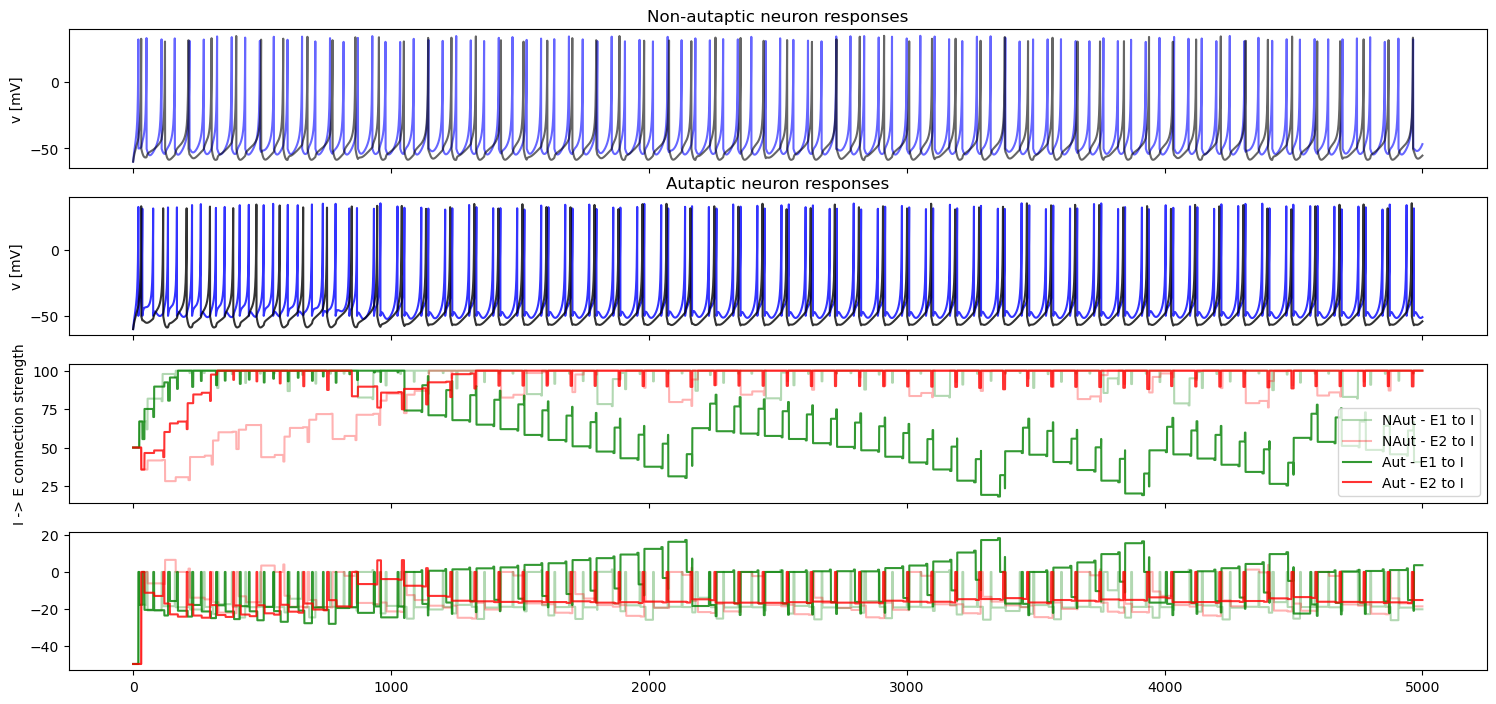

In [6]:
### Plot the outputs for each trial

# 1. SIMPLY PLOT THE TRACES

fig, ax = plt.subplots(4, 1, figsize = (15, 7), sharex = True)
fig.tight_layout()

#plot non-autaptic neurons
ax[0].plot(M_v_E.t/ms, M_v_E.v[0], c = 'blue', alpha = 0.6, label = 'non-autaptic neuron 1')
ax[0].plot(M_v_E.t/ms, M_v_E.v[1], c = 'black', alpha = 0.6, label = 'non-autaptic neuron 2')
ax[0].set_title('Non-autaptic neuron responses')
ax[0].set_ylabel('v [mV]')

# plot autaptic neurons
ax[1].plot(M_v_E_aut.t/ms, M_v_E_aut.v[0], c = 'blue', alpha = 0.8, label = 'autaptic neuron 1')
ax[1].plot(M_v_E_aut.t/ms, M_v_E_aut.v[1], c = 'black', alpha = 0.8, label = 'non-autaptic neuron 2')
ax[1].set_title('Autaptic neuron responses')
ax[1].set_ylabel('v [mV]')

# plot synapse variables at the inhibitory neuron
ax[2].plot(M_syn_EI.t/ms, M_syn_EI.w_exc[0], c = 'green', alpha = 0.3, label = 'NAut - E1 to I')
ax[2].plot(M_syn_EI.t/ms, M_syn_EI.w_exc[1], c = 'red', alpha = 0.3, label = 'NAut - E2 to I')
ax[2].plot(M_syn_EI_aut.t/ms, M_syn_EI_aut.w_exc[0], c = 'green', alpha = 0.8, label = 'Aut - E1 to I')
ax[2].plot(M_syn_EI_aut.t/ms, M_syn_EI_aut.w_exc[1], c = 'red', alpha = 0.8, label = 'Aut - E2 to I')
ax[2].set_ylabel("E -> I connection strength")
ax[2].legend()

# plot synapse variables at the inhibitory neuron
ax[3].plot(M_syn_IE.t/ms, M_syn_IE.w_inh[0], c = 'green', alpha = 0.3, label = 'NAut - E1 to I')
ax[3].plot(M_syn_IE.t/ms, M_syn_IE.w_inh[1], c = 'red', alpha = 0.3, label = 'NAut - E2 to I')
ax[3].plot(M_syn_IE_aut.t/ms, M_syn_IE_aut.w_inh[0], c = 'green', alpha = 0.8, label = 'Aut - E1 to I')
ax[3].plot(M_syn_IE_aut.t/ms, M_syn_IE_aut.w_inh[1], c = 'red', alpha = 0.8, label = 'Aut - E2 to I')
ax[2].set_ylabel("I -> E connection strength")
ax[2].legend()


In [7]:
"""
## Plot the ISI distribution for the trials above
spikes_E = convert_spikes_to_aqua(spike_trains_E)
spikes_E_aut = convert_spikes_to_aqua(spike_trains_E_aut)

fig, ax = plt.subplots(2, 2, figsize = (8, 8), sharex = True)

bins = 50
range = (0, 100)
x_range = np.linspace(range[0], range[1], bins)

E1_hist, bin_edges = np.histogram(np.ediff1d(spikes_E[0]), bins = bins, range = range)
bin_edges = bin_edges[:-1]
bin_spacing = bin_edges[1] - bin_edges[0]

peaks_E1 = find_peaks(E1_hist, threshold = 10)[0]
N_peaks = len(peaks_E1)

widths_E1, width_height_E1, left_ips, right_ips = peak_widths(E1_hist, peaks_E1)
print(left_ips)
left_ips = np.rint(left_ips, 0)
right_ips = np.rint(right_ips, 0)
print("- - - -")
x_loc = (bin_edges[left_ips] + bin_spacing/2)
print(x_loc)
dx = (bin_edges[right_ips] + bin_spacing/2) - x_loc
print(dx)
fig, ax[0, 0] = plot_ISI_dist(spikes_E[0], bins = bins, range = range, fig = fig, ax = ax[0, 0])
ax[0, 0].vlines(bin_edges[peaks_E1] + bin_spacing/2, ymin = np.zeros(N_peaks), ymax = 1.1*np.max(E1_hist)*np.ones(N_peaks), colors = 'red', linestyles = 'dashed')
ax[0, 0].arrow(x = x_loc, y = width_height_E1[0], dx = dx, dy = 0, colors = 'purple', arrowstyle = '<->')
ax[0, 0].set_title("E1 - no autapse")

fig, ax[0, 1] = plot_ISI_dist(spikes_E[1], bins = bins, range = range, fig = fig, ax = ax[0, 1])
ax[0, 1].set_title("E2 - no autapse")

fig, ax[1, 0] = plot_ISI_dist(spikes_E_aut[0], bins = bins, range = range, fig = fig, ax = ax[1, 0])
ax[1, 0].set_title("E1 - w/ autapse")

fig, ax[1, 1] = plot_ISI_dist(spikes_E_aut[1], bins = bins, range = range, fig = fig, ax = ax[1, 1])
ax[1, 1].set_title("E2 - w/ autapse")
"""

'\n## Plot the ISI distribution for the trials above\nspikes_E = convert_spikes_to_aqua(spike_trains_E)\nspikes_E_aut = convert_spikes_to_aqua(spike_trains_E_aut)\n\nfig, ax = plt.subplots(2, 2, figsize = (8, 8), sharex = True)\n\nbins = 50\nrange = (0, 100)\nx_range = np.linspace(range[0], range[1], bins)\n\nE1_hist, bin_edges = np.histogram(np.ediff1d(spikes_E[0]), bins = bins, range = range)\nbin_edges = bin_edges[:-1]\nbin_spacing = bin_edges[1] - bin_edges[0]\n\npeaks_E1 = find_peaks(E1_hist, threshold = 10)[0]\nN_peaks = len(peaks_E1)\n\nwidths_E1, width_height_E1, left_ips, right_ips = peak_widths(E1_hist, peaks_E1)\nprint(left_ips)\nleft_ips = np.rint(left_ips, 0)\nright_ips = np.rint(right_ips, 0)\nprint("- - - -")\nx_loc = (bin_edges[left_ips] + bin_spacing/2)\nprint(x_loc)\ndx = (bin_edges[right_ips] + bin_spacing/2) - x_loc\nprint(dx)\nfig, ax[0, 0] = plot_ISI_dist(spikes_E[0], bins = bins, range = range, fig = fig, ax = ax[0, 0])\nax[0, 0].vlines(bin_edges[peaks_E1] + bin_

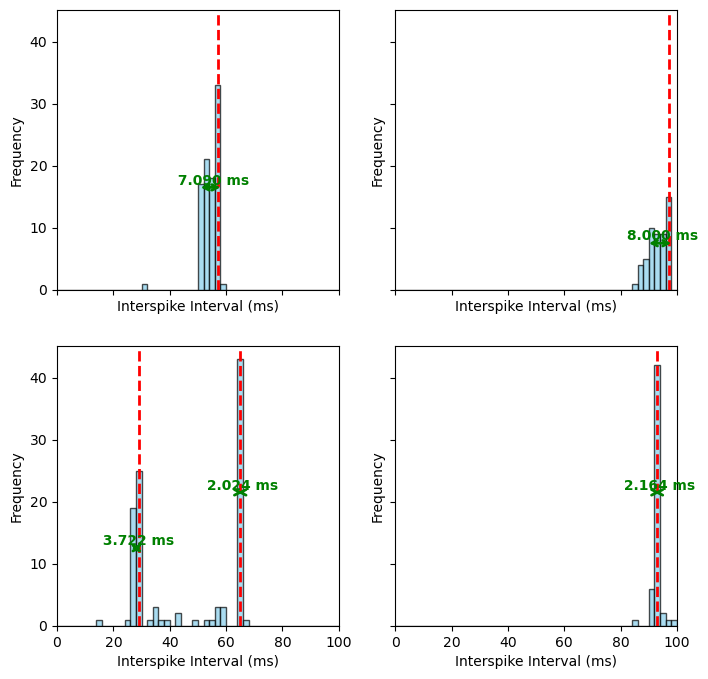

In [8]:
from functions import *

spikes_E = convert_spikes_to_aqua(spike_trains_E)
spikes_E_aut = convert_spikes_to_aqua(spike_trains_E_aut)

fig, ax = plt.subplots(2, 2, figsize = (8, 8), sharex = True, sharey = True)
bins = 50
x_range = (0, 100)


plot_ISI_w_peaks(spikes_E[0], bins = bins, x_range = x_range, fig = fig, ax = ax[0, 0])
plot_ISI_w_peaks(spikes_E[1], bins = bins, x_range = x_range, fig = fig, ax = ax[0, 1])

plot_ISI_w_peaks(spikes_E_aut[0], bins = bins, x_range = x_range, fig = fig, ax = ax[1, 0])
plot_ISI_w_peaks(spikes_E_aut[1], bins = bins, x_range = x_range, fig = fig, ax = ax[1, 1])


Text(62.597222222222214, 0.5, 'fft')

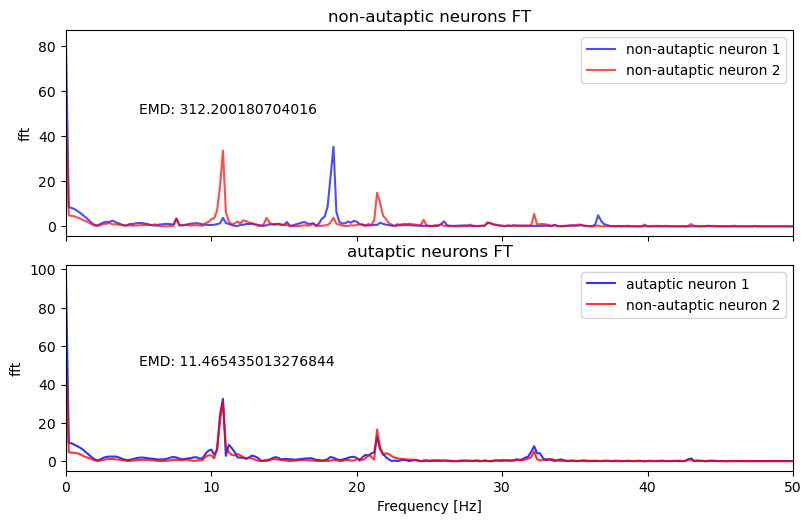

In [9]:
''' - - -  2. PLOT THE FOURIER TRANSFORMS OF THE SPIKING ACTIVITY - - - '''
#binarise spike trains

binary_E = binarise_spikes(spikes_E, dt, N_iter)
binary_E_aut = binarise_spikes(spikes_E_aut, dt, N_iter)


# create filter
gauss = windows.gaussian(M = 10000, std = 100)
gauss /= gauss.sum()    # normalise

# - - CONVOLVE - - 
# convolve non-autaptic spike trains
freqE1 = convolve(binary_E[0, :], gauss)[:len(binary_E[0, :])]
freqE2 = convolve(binary_E[1, :], gauss)[:len(binary_E[1, :])]
# convolve autaptic spike trains
freqE1_aut = convolve(binary_E_aut[0, :], gauss)[:len(binary_E_aut[0, :])]
freqE2_aut = convolve(binary_E_aut[1, :], gauss)[:len(binary_E_aut[1, :])]


# - - calculate the FFT - - 
fftE1 = np.fft.fft(freqE1)
fftE2 = np.fft.fft(freqE2)

fftE1_aut = np.fft.fft(freqE1_aut)
fftE2_aut = np.fft.fft(freqE2_aut)


# x-axis - frequencies
fftfreq = np.fft.fftfreq(N_iter, d = dt/1000)
n_freq = len(fftfreq)//2

## Calculate the Wasserstein/EMD distance
EMD_naut = wasserstein_distance(fftfreq[:n_freq], fftfreq[:n_freq], np.abs(fftE1[:n_freq]), np.abs(fftE2[:n_freq]))
EMD_aut = wasserstein_distance(fftfreq[:n_freq], fftfreq[:n_freq], np.abs(fftE1_aut[:n_freq]), np.abs(fftE2_aut[:n_freq]))


fig, ax = plt.subplots(2, 1, figsize = (8, 5), sharex = True)
fig.tight_layout()

ax[0].plot(fftfreq[:n_freq], np.abs(fftE1[:n_freq]), c = 'blue', alpha = 0.7, label = 'non-autaptic neuron 1')
ax[0].plot(fftfreq[:n_freq], np.abs(fftE2[:n_freq]), c = 'red', alpha = 0.7, label = 'non-autaptic neuron 2')
ax[0].text(5, 50, f'EMD: {EMD_naut}')
ax[0].legend()

ax[1].plot(fftfreq[:n_freq], np.abs(fftE1_aut[:n_freq]), c = 'blue', alpha = 0.8, label = 'autaptic neuron 1')
ax[1].plot(fftfreq[:n_freq], np.abs(fftE2_aut[:n_freq]), c = 'red', alpha = 0.8, label = 'non-autaptic neuron 2')
ax[1].text(5, 50, f'EMD: {EMD_aut}')
ax[1].legend()


ax[0].set_xlim((0, 50))
ax[1].set_xlim((0, 50))

ax[0].set_title('non-autaptic neurons FT')
ax[1].set_title('autaptic neurons FT')
ax[1].set_xlabel("Frequency [Hz]")
ax[0].set_ylabel('fft')
ax[1].set_ylabel('fft')

In [10]:
'''FT distance'''
# calculate FFT
_, freq = calculate_FT(binary_E_aut[0, :], dt, gauss)
fft_E1_aut = calculate_FT(binary_E_aut[0, :], dt, gauss)[0]
fft_E2_aut = calculate_FT(binary_E_aut[1, :], dt, gauss)[0]

fft_E1_naut = calculate_FT(binary_E[0, :], dt, gauss)[0]
fft_E2_naut = calculate_FT(binary_E[1, :], dt, gauss)[0]

diff_aut = calculate_FT_diff(fft_E1_aut, fft_E2_aut, freq)
diff_naut = calculate_FT_diff(fft_E1_naut, fft_E2_naut, freq)

print(diff_aut)
print(diff_naut)


0.429498942302924
0.968015682694631


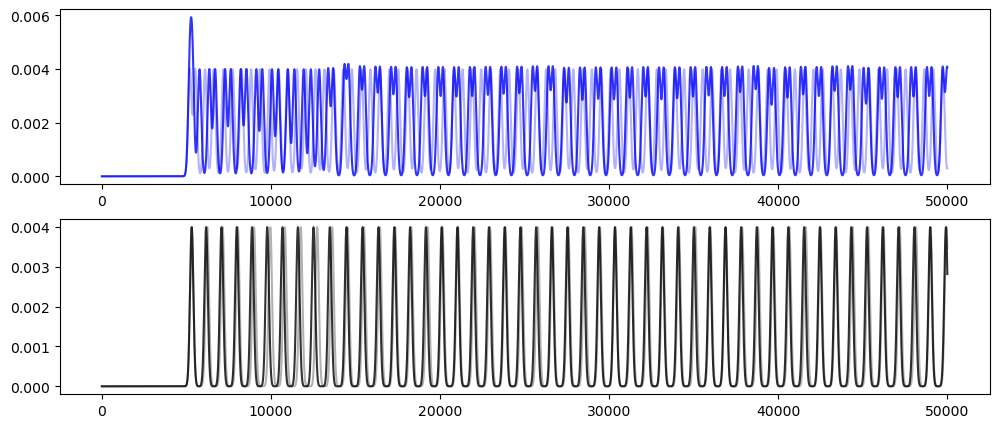

In [11]:

fig, ax = plt.subplots(2, 1, figsize = (12, 5))

ax[0].plot(freqE1, c = 'blue', alpha = 0.3)
ax[0].plot(freqE1_aut, c = 'blue', alpha = 0.8)

ax[1].plot(freqE2, c = 'black', alpha = 0.3)
ax[1].plot(freqE2_aut, c = 'black', alpha = 0.8)


In [12]:
'''
Test the rolling difference

print(len(binary_E[0, :]))

window = 10000
rolling_FT_non = rolling_FT_diff(binary_E[0, :], binary_E[1, :], dt, window = window)
rolling_FT_aut = rolling_FT_diff(binary_E_aut[0, :], binary_E_aut[1, :], dt, window = window)
'''

'\nTest the rolling difference\n\nprint(len(binary_E[0, :]))\n\nwindow = 10000\nrolling_FT_non = rolling_FT_diff(binary_E[0, :], binary_E[1, :], dt, window = window)\nrolling_FT_aut = rolling_FT_diff(binary_E_aut[0, :], binary_E_aut[1, :], dt, window = window)\n'

In [13]:
'''
fig, ax = plt.subplots(4, 1, figsize = (15, 7), sharex = True)
fig.tight_layout()

time = np.linspace(0, (len(binary_E[0, :]) - window)*dt, len(rolling_FT_non))
ax[0].plot(M_v_E.t/ms, M_v_E.v[0], c = 'blue', alpha = 0.3, label = 'non-autaptic neuron 1')
ax[0].plot(M_v_E.t/ms, M_v_E.v[1], c = 'black', alpha = 0.3, label = 'non-autaptic neuron 2')
ax[0].set_title('Non-autaptic neuron responses')
ax[0].set_ylabel('v [mV]')

ax[1].plot(time, rolling_FT_non, c = 'purple', alpha = 0.3, label = 'non-autaptic')
ax[1].set_title("rolling FT distance of non-autaptic neuron network")
ax[1].set_ylabel("FT distance")
ax[1].set_ylim((0, 2))

# plot autaptic neurons
ax[2].plot(M_v_E_aut.t/ms, M_v_E_aut.v[0], c = 'blue', alpha = 0.8, label = 'autaptic neuron 1')
ax[2].plot(M_v_E_aut.t/ms, M_v_E_aut.v[1], c = 'black', alpha = 0.8, label = 'non-autaptic neuron 2')
ax[2].set_title('Autaptic neuron responses')
ax[2].set_ylabel('v [mV]')

ax[3].plot(time, rolling_FT_aut, c = 'red', alpha = 0.8, label = 'autaptic')
ax[3].set_title("rolling FT distance of autaptic neuron network")
ax[3].set_ylabel("FT distance")
ax[3].set_ylim((0, 2))
'''

'\nfig, ax = plt.subplots(4, 1, figsize = (15, 7), sharex = True)\nfig.tight_layout()\n\ntime = np.linspace(0, (len(binary_E[0, :]) - window)*dt, len(rolling_FT_non))\nax[0].plot(M_v_E.t/ms, M_v_E.v[0], c = \'blue\', alpha = 0.3, label = \'non-autaptic neuron 1\')\nax[0].plot(M_v_E.t/ms, M_v_E.v[1], c = \'black\', alpha = 0.3, label = \'non-autaptic neuron 2\')\nax[0].set_title(\'Non-autaptic neuron responses\')\nax[0].set_ylabel(\'v [mV]\')\n\nax[1].plot(time, rolling_FT_non, c = \'purple\', alpha = 0.3, label = \'non-autaptic\')\nax[1].set_title("rolling FT distance of non-autaptic neuron network")\nax[1].set_ylabel("FT distance")\nax[1].set_ylim((0, 2))\n\n# plot autaptic neurons\nax[2].plot(M_v_E_aut.t/ms, M_v_E_aut.v[0], c = \'blue\', alpha = 0.8, label = \'autaptic neuron 1\')\nax[2].plot(M_v_E_aut.t/ms, M_v_E_aut.v[1], c = \'black\', alpha = 0.8, label = \'non-autaptic neuron 2\')\nax[2].set_title(\'Autaptic neuron responses\')\nax[2].set_ylabel(\'v [mV]\')\n\nax[3].plot(time, r

ISI distance: 0.41513586
ISI distance (autapse): 0.43293016


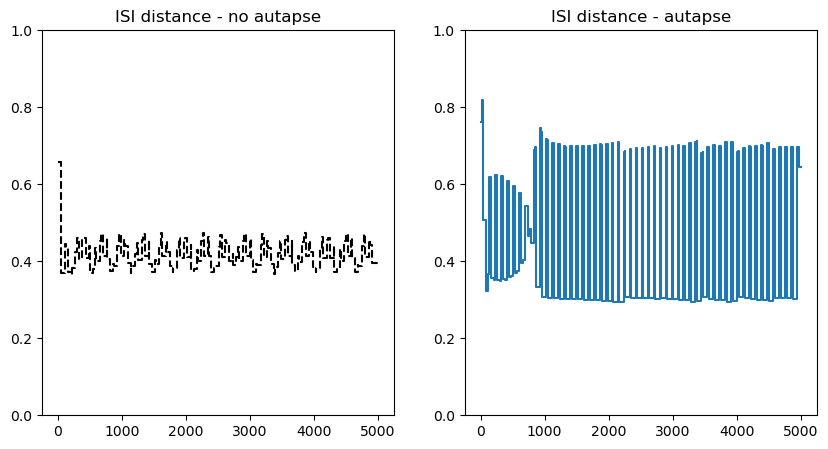

In [14]:
'''
- - - ISI DISTANCE - - - 

'''

# convert to pyspike SpikeTrain object
edges = [0.0, T]
spk_E_aut = [spk.SpikeTrain(spikes_E_aut[i], edges) for i in range(np.shape(spikes_E_aut)[0])]
spk_E = [spk.SpikeTrain(spikes_E[i], edges) for i in range(np.shape(spikes_E)[0])]

'''- - ISI distance - - '''
isi_profile_aut = spk.isi_profile(spk_E_aut[0], spk_E_aut[1])
isi_profile = spk.isi_profile(spk_E[0], spk_E[1])

x_aut, y_aut = isi_profile_aut.get_plottable_data()
x, y = isi_profile.get_plottable_data()

fig, ax = plt.subplots(1, 2, figsize = (10, 5))
ax[0].plot(x, y, '--k', label = 'no autapse')
ax[0].set_title('ISI distance - no autapse')
ax[1].plot(x_aut, y_aut, label = 'autapse')
ax[1].set_title('ISI distance - autapse')

ax[0].set_ylim((0, 1))
ax[1].set_ylim((0, 1))
print("ISI distance: %.8f" % isi_profile.avrg())
print("ISI distance (autapse): %.8f" % isi_profile_aut.avrg())
plt.show()



SPIKE distance: 0.26033157
SPIKE distance (autapse): 0.19652661
A-SPIKE distance: 0.25954458
A-SPIKE distance (autapse): 0.19005100


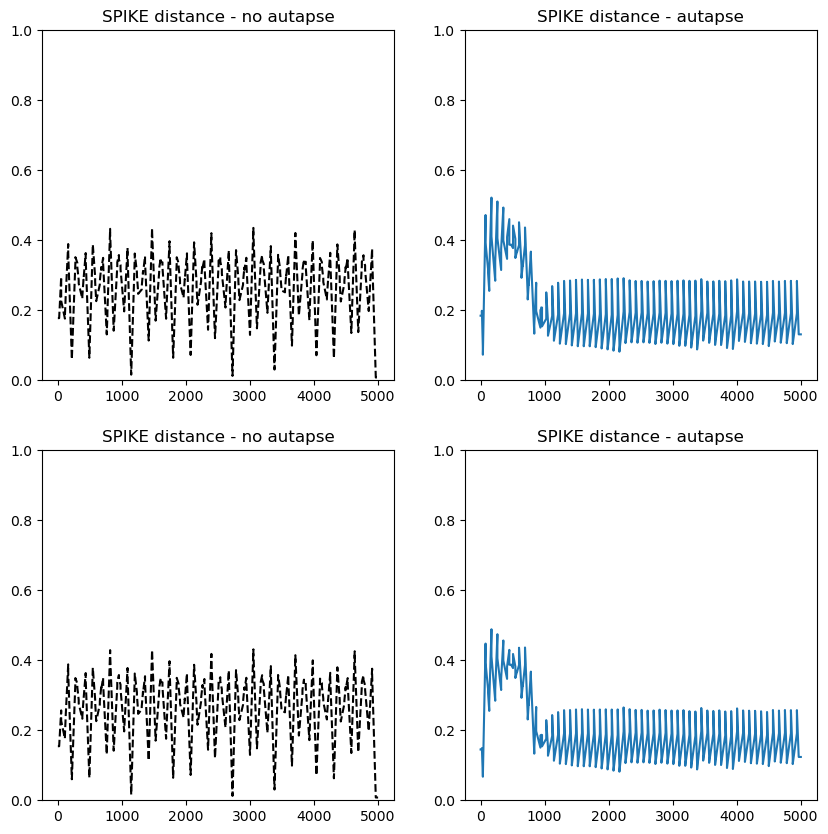

In [15]:
'''- - SPIKE distance - - '''
spike_profile_aut = spk.spike_profile(spk_E_aut[0], spk_E_aut[1])
spike_profile = spk.spike_profile(spk_E[0], spk_E[1])

x_aut, y_aut = spike_profile_aut.get_plottable_data()
x, y = spike_profile.get_plottable_data()

'''- - RI SPIKE distance'''
spike_profile_aut_RI = spk.spike_profile(spk_E_aut[0], spk_E_aut[1], MRTS = 'auto')
spike_profile_RI = spk.spike_profile(spk_E[0], spk_E[1], MRTS = 'auto')

x_aut_RI, y_aut_RI = spike_profile_aut_RI.get_plottable_data()
x_RI, y_RI = spike_profile_RI.get_plottable_data()


fig, ax = plt.subplots(2, 2, figsize = (10, 10))
ax[0,0].plot(x, y, '--k', label = 'no autapse')
ax[0,0].set_title('SPIKE distance - no autapse')
ax[0,1].plot(x_aut, y_aut, label = 'autapse')
ax[0,1].set_title('SPIKE distance - autapse')

ax[1,0].plot(x_RI, y_RI, '--k', label = 'no autapse')
ax[1,0].set_title('SPIKE distance - no autapse')
ax[1,1].plot(x_aut_RI, y_aut_RI, label = 'autapse')
ax[1,1].set_title('SPIKE distance - autapse')

ax[0,0].set_ylim((0, 1))
ax[0,1].set_ylim((0, 1))
ax[1,0].set_ylim((0, 1))
ax[1,1].set_ylim((0, 1))
print("SPIKE distance: %.8f" % spike_profile.avrg())
print("SPIKE distance (autapse): %.8f" % spike_profile_aut.avrg())
print("A-SPIKE distance: %.8f" % spike_profile_RI.avrg())
print("A-SPIKE distance (autapse): %.8f" % spike_profile_aut_RI.avrg())
plt.show()

SPIKE synch: 0.73972603
SPIKE synch (autapse): 0.58024691


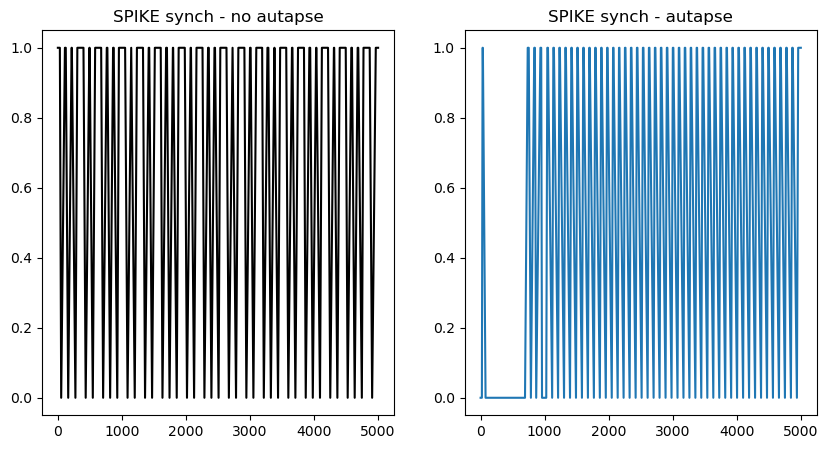

In [16]:
'''- - SPIKE synch - - '''
spike_profile_aut = spk.spike_sync_profile(spk_E_aut[0], spk_E_aut[1])
spike_profile = spk.spike_sync_profile(spk_E[0], spk_E[1])

x_aut, y_aut = spike_profile_aut.get_plottable_data()
x, y = spike_profile.get_plottable_data()

fig, ax = plt.subplots(1, 2, figsize = (10, 5))
ax[0].plot(x, y, 'k', label = 'no autapse')
ax[0].set_title('SPIKE synch - no autapse')
ax[1].plot(x_aut, y_aut, label = 'autapse')
ax[1].set_title('SPIKE synch - autapse')


print("SPIKE synch: %.8f" % spike_profile.avrg())
print("SPIKE synch (autapse): %.8f" % spike_profile_aut.avrg())
plt.show()

Spike train directionality (autapse): -0.37962962962962965
Spike train directionality: 0.06521739130434782
[  20.3   51.9  110.2  161.5  218.5  274.   325.6  382.4  434.5  491.6
  545.6  598.8  655.1  706.6  763.6  816.2  871.7  927.6  978.7 1035.5
 1088.2 1145.2 1200.5 1253.  1309.5 1361.1 1418.1 1471.2 1526.1 1582.
 1633.2 1690.2 1743.6 1800.2 1855.9 1907.4 1964.  2016.  2073.  2127.
 2180.5 2236.7 2288.1 2345.1 2397.4 2453.5 2509.2 2560.4 2617.2 2669.7
 2726.7 2781.8 2835.  2891.4 2943.  3000.1 3052.8 3108.4 3164.3 3215.4
 3272.3 3325.4 3382.4 3437.9 3490.  3546.5 3598.3 3655.3 3708.5 3762.9
 3818.9 3870.1 3927.  3980.2 4036.9 4092.7 4144.1 4200.8 4252.9 4310.
 4364.  4417.3 4473.5 4525.  4582.  4634.5 4690.2 4746.  4797.2 4854.1
 4906.8 4963.8]


Text(0.5, 1.0, 'Spike Train Order Profile (autapse)')

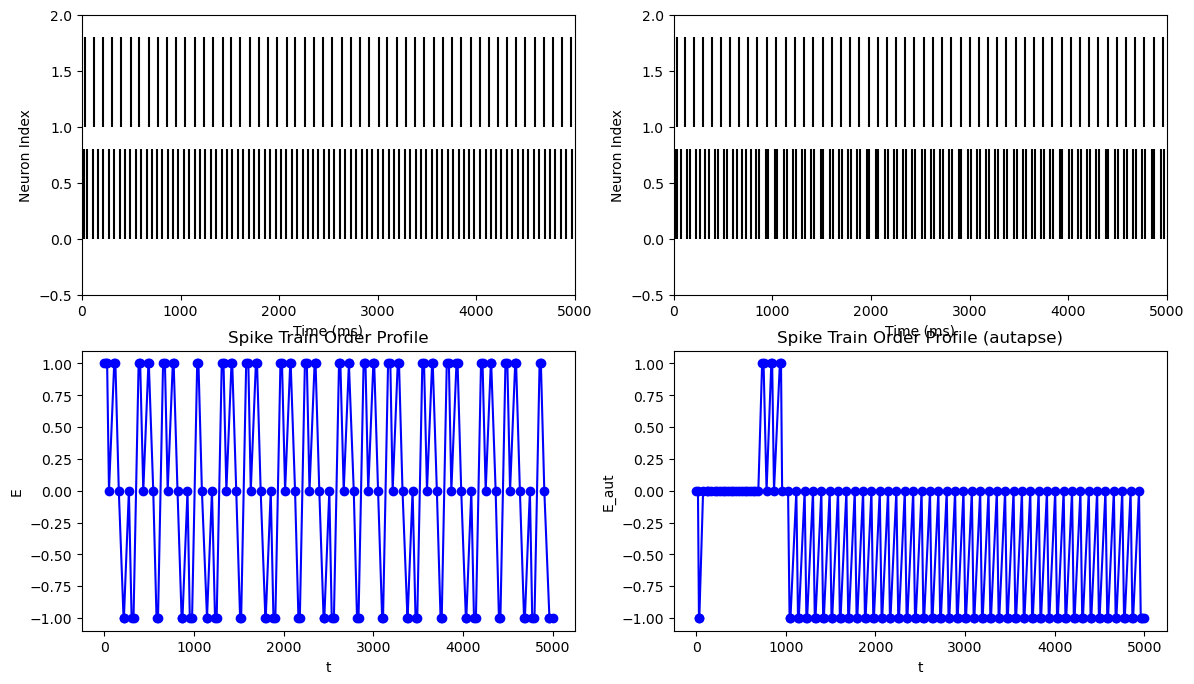

In [17]:
'''- - - SPIKE TRAIN ORDER - - -'''

d_aut = spk.spike_directionality(spk_E_aut[0], spk_E_aut[1])
d = spk.spike_directionality(spk_E[0], spk_E[1])

print(f"Spike train directionality (autapse): {d_aut}")
print(f"Spike train directionality: {d}")

E_aut = spk.spike_train_order_profile(spk_E_aut[0], spk_E_aut[1])
E = spk.spike_train_order_profile(spk_E[0], spk_E[1])

x_aut, y_aut = E_aut.get_plottable_data()
x, y = E.get_plottable_data()

fig, ax = plt.subplots(2, 2, figsize = (14, 8))

print(spikes_E[0, :])

fig, ax[0,0] = plot_raster(spikes_E, T, ax = ax[0,0])
fig, ax[0,1] = plot_raster(spikes_E_aut, T, ax = ax[0,1])

ax[1,0].plot(x, y, '-ob')
ax[1,0].set_ylim(-1.1, 1.1)
ax[1,0].set_xlabel("t")
ax[1,0].set_ylabel("E")
ax[1,0].set_title("Spike Train Order Profile")

ax[1,1].plot(x_aut, y_aut, '-ob')
ax[1,1].set_ylim(-1.1, 1.1)
ax[1,1].set_xlabel("t")
ax[1,1].set_ylabel("E_aut")
ax[1,1].set_title("Spike Train Order Profile (autapse)")
